# 1. Global Settings and Initiation

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# XGBoost
import xgboost as xgb
from xgboost import XGBRegressor

# CatBoost
from catboost import CatBoostRegressor, Pool

# LightGBM
import lightgbm as lgb
from lightgbm import LGBMRegressor, log_evaluation, early_stopping

from sklearn.metrics import mean_squared_log_error

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)

sns.set_style("whitegrid")

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [3]:
print("Searching for .pkl files...")
found = False
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.pkl'):
            print(f"FOUND: {os.path.join(dirname, filename)}")
            found = True

if not found:
    print("Still nothing. The dataset is not attached yet.")

Searching for .pkl files...
FOUND: /kaggle/input/final-data-from-preprocessing/y_train.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/X_val.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/test.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/X_train.pkl
FOUND: /kaggle/input/final-data-from-preprocessing/y_val.pkl


In [4]:
base_path = '/kaggle/input/final-data-from-preprocessing/'

# Load the files
X_train = pd.read_pickle(f'{base_path}X_train.pkl')
y_train = pd.read_pickle(f'{base_path}y_train.pkl')
X_val   = pd.read_pickle(f'{base_path}X_val.pkl')
y_val   = pd.read_pickle(f'{base_path}y_val.pkl')
test    = pd.read_pickle(f'{base_path}test.pkl')

print("Data Loaded!")

Data Loaded!


In [5]:
# --- Evaluation metrics helper ---
import numpy as np

def evaluate_forecast(y_true, y_pred, y_train=None, seasonality=7, eps=1e-9):
    import numpy as np
    from sklearn.metrics import mean_squared_log_error

    # --- FIX: force 1D numpy arrays (prevents (n,1)-(n,) broadcasting to (n,n)) ---
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"Shape mismatch: y_true={y_true.shape}, y_pred={y_pred.shape}")

    # Clip to non-negative (sales)
    y_pred_clip = np.clip(y_pred, 0, None)
    y_true_clip = np.clip(y_true, 0, None)

    err = y_pred_clip - y_true_clip
    mae = np.mean(np.abs(err))
    # rmse = np.sqrt(np.mean(err**2)) # redundant with MAE

    # RMSLE (safe)
    rmsle = np.sqrt(mean_squared_log_error(y_true_clip, y_pred_clip))

    # MAPE (ignore zeros in denom)
    # mask = y_true_clip > 0
    # mape = np.mean(np.abs(err[mask] / (y_true_clip[mask] + eps))) if np.any(mask) else np.nan # unstable with zero sales

    # sMAPE (works with zeros)
    smape = np.mean(2.0 * np.abs(err) / (np.abs(y_true_clip) + np.abs(y_pred_clip) + eps))

    # Bias
    bias = np.mean(err)

    # MASE (optional, needs y_train)
    mase = np.nan
    if y_train is not None:
        y_train = np.asarray(y_train).reshape(-1)
        if y_train.shape[0] > seasonality:
            naive_err = np.abs(y_train[seasonality:] - y_train[:-seasonality])
            denom = np.mean(naive_err) + eps
            mase = mae / denom

    return {
        # "RMSE": rmse,
        "MAE": mae,
        "RMSLE": rmsle,
        # "MAPE": mape,
        "sMAPE": smape,
        "Bias": bias,
        "MASE": mase,
    }


def print_metrics(title, metrics_dict):
    print(f"\n{title}")
    for k, v in metrics_dict.items():
        if v is None or (isinstance(v, float) and np.isnan(v)):
            print(f"  {k:7s}: NA")
        elif "MAPE" in k or "sMAPE" in k:
            print(f"  {k:7s}: {v:8.3f}")
        else:
            print(f"  {k:7s}: {v:8.5f}")


In [6]:
# -----------------------------------------------------------------------------
# DEFINE FEATURE GROUPS
# -----------------------------------------------------------------------------

id = 'id'
timestamp = ['date']
target = ['sales']

CATEGORICAL = [
    ### train & test
    'store_nbr',
    'family',
    ### store
    'store_city',
    'store_state',
    'store_type',
    'store_cluster', 
    ### holiday 
    'h_type_nat',
    'h_type_reg',
    'h_type_loc',
]

BOOLEAN = [
    ### time related
    'is_weekend',
    'is_public_payday',
    ### holiday
    'is_national_holiday',
    'is_regional_holiday',
    'is_local_holiday'    
]

NUMERICAL = [
    ### train & test
    'onpromotion',
    ### time related
    'year',
    'month_sin',
    'month_cos',
    'day_sin',
    'day_cos',
    'dow_sin',
    'dow_cos',
    'quarter_sin',
    'quarter_cos',
    ### oil
    'daily_oil_price',
    ### transactions
    # 'transactions',
    # 'log_transactions',
    # 'transactions_rolling_7',
    ### lag r
    # 'sales_lag_7',
]

# Combine all features
FEATURES = CATEGORICAL + BOOLEAN + NUMERICAL

# Define cat_features for CatBoost/LightGBM
cat_features = CATEGORICAL

print(f"Total Features: {len(FEATURES)}")
print(f"Categorical Features: {cat_features}")

Total Features: 25
Categorical Features: ['store_nbr', 'family', 'store_city', 'store_state', 'store_type', 'store_cluster', 'h_type_nat', 'h_type_reg', 'h_type_loc']


In [7]:
# Target Transformation (Log1p)
# This makes the default RMSE objective optimize for RMSLE
y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)

In [8]:
!pip install optuna

# 2. Models

## 2.1. CatBoost

In [9]:
train_pool = Pool(
    data=X_train[FEATURES], 
    label=y_train_log, 
    cat_features=cat_features
)

val_pool = Pool(
    data=X_val[FEATURES], 
    label=y_val_log, 
    cat_features=cat_features
)

print("Pools created successfully.")

Pools created successfully.


In [10]:
import optuna
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error

def objective_cat(trial):
    params = {
        'task_type': 'GPU',
        'devices': '0:1',
        'iterations': 3000,
        'loss_function': 'RMSE',
        'random_seed': 42,
        'verbose': 0,
        'early_stopping_rounds': 50,
        
        # Knobs to Tune:
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 10),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
    }
    
    # Initialize Model
    model = CatBoostRegressor(**params)
    
    # Train)
    model.fit(train_pool, eval_set=val_pool)
    
    # Predict & Evaluate
    preds_log = model.predict(val_pool)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds_log))
    
    return rmse

# --- OPTIMIZATION ---
print("Starting CatBoost Hyperparameter Tuning...")
study_cat = optuna.create_study(direction='minimize')
study_cat.optimize(objective_cat, n_trials=20) 

print("\n------------------------------------------------")
print(f"BEST TRIAL RMSE: {study_cat.best_value:.5f}")
print("BEST PARAMS: ")
for key, value in study_cat.best_params.items():
    print(f"    {key}: {value}")
print("------------------------------------------------")

[I 2026-01-18 07:12:54,959] A new study created in memory with name: no-name-6b409445-fa93-47c8-ba6f-a653b297e353


Starting CatBoost Hyperparameter Tuning...


[I 2026-01-18 07:28:39,165] Trial 0 finished with value: 0.5988631400698862 and parameters: {'learning_rate': 0.016123093895094205, 'depth': 10, 'l2_leaf_reg': 2, 'min_data_in_leaf': 2}. Best is trial 0 with value: 0.5988631400698862.
[I 2026-01-18 07:43:48,139] Trial 1 finished with value: 0.6009358073732942 and parameters: {'learning_rate': 0.02792073350427634, 'depth': 10, 'l2_leaf_reg': 10, 'min_data_in_leaf': 78}. Best is trial 0 with value: 0.5988631400698862.
[I 2026-01-18 07:49:03,946] Trial 2 finished with value: 0.6000118722027707 and parameters: {'learning_rate': 0.05508482980163758, 'depth': 10, 'l2_leaf_reg': 9, 'min_data_in_leaf': 45}. Best is trial 0 with value: 0.5988631400698862.
[I 2026-01-18 07:54:35,657] Trial 3 finished with value: 0.6094039781163993 and parameters: {'learning_rate': 0.0998201531842865, 'depth': 6, 'l2_leaf_reg': 8, 'min_data_in_leaf': 95}. Best is trial 0 with value: 0.5988631400698862.
[I 2026-01-18 07:57:43,891] Trial 4 finished with value: 0.68

KeyboardInterrupt: 

In [12]:
cat_model = CatBoostRegressor(
    task_type= 'GPU',
    devices= '0:1',
    iterations= 3000,
    learning_rate= 0.03,
    depth= 10,
    l2_leaf_reg= 2,
    min_data_in_leaf= 2,
    loss_function= 'RMSE',
    random_seed= 42,
    verbose= 100,
    early_stopping_rounds= 50
)

cat_model.fit(train_pool, eval_set=val_pool)

0:	learn: 2.5012742	test: 2.4476870	best: 2.4476870 (0)	total: 294ms	remaining: 14m 41s
100:	learn: 0.8331895	test: 0.7734384	best: 0.7734384 (100)	total: 31.3s	remaining: 14m 57s
200:	learn: 0.7013575	test: 0.6996675	best: 0.6996675 (200)	total: 1m 2s	remaining: 14m 33s
300:	learn: 0.6313234	test: 0.6715287	best: 0.6715287 (300)	total: 1m 33s	remaining: 13m 57s
400:	learn: 0.5891801	test: 0.6541067	best: 0.6541067 (400)	total: 2m 4s	remaining: 13m 24s
500:	learn: 0.5609333	test: 0.6421290	best: 0.6421066 (499)	total: 2m 34s	remaining: 12m 51s
600:	learn: 0.5394627	test: 0.6328265	best: 0.6328265 (600)	total: 3m 5s	remaining: 12m 21s
700:	learn: 0.5231208	test: 0.6259335	best: 0.6259335 (700)	total: 3m 36s	remaining: 11m 50s
800:	learn: 0.5111191	test: 0.6216562	best: 0.6216558 (798)	total: 4m 7s	remaining: 11m 19s
900:	learn: 0.5015031	test: 0.6185070	best: 0.6184925 (899)	total: 4m 38s	remaining: 10m 48s
1000:	learn: 0.4925509	test: 0.6155995	best: 0.6155037 (996)	total: 5m 8s	remain

In [13]:
# 1. Get the Raw Log Predictions from the model
cat_pred_log = cat_model.predict(val_pool)

cat_pred_real = np.expm1(cat_pred_log)
cat_pred_real = np.maximum(cat_pred_real, 0)

# 3. Calculate the True RMSLE
# We use y_val (Real Targets) vs y_pred_real (Real Predictions)
# sklearn's mean_squared_log_error handles the log math internally
try:
    cat_rmsle = np.sqrt(mean_squared_log_error(y_val, cat_pred_real))
    print(f"Validation RMSLE: {cat_rmsle:.5f}")
except Exception as e:
    print("Error calculating RMSLE. Ensure y_val is in 'Real Sales' units (not logged).")
    print(e)

# Evaluation metrics
CatBoost_metrics = evaluate_forecast(y_val, cat_pred_real, y_train=y_train, seasonality=7)
print_metrics("CatBoost validation metrics", CatBoost_metrics)

Validation RMSLE: 0.59804

CatBoost validation metrics
  MAE    : 108.02065
  RMSLE  :  0.59804
  sMAPE  :    0.566
  Bias   : -74.15437
  MASE   :  1.15414


In [14]:
cat_profile = profile_trained_model(
    "catboost",
    predict_fn=lambda: cat_model.predict(val_pool),
    n_rows=val_pool.num_row(),
    save_fn=lambda path: cat_model.save_model(path),
    run_twice=True
)

cat_pred_log = cat_profile["preds"]
print({k:v for k,v in cat_profile.items() if k!="preds"})


NameError: name 'profile_trained_model' is not defined

**Feature Importance for CatBoost**

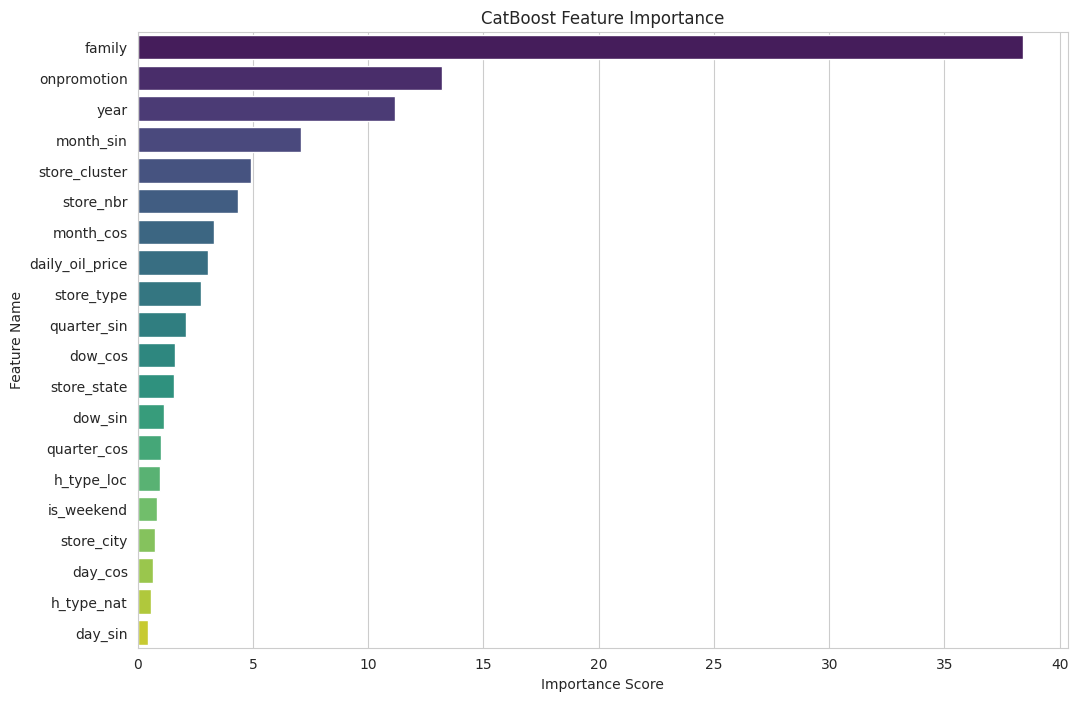

Zero Importance Features: []


In [15]:
# 1. Get the scores
feature_importance = cat_model.get_feature_importance()

# 2. Get the feature names
feature_names = cat_model.feature_names_ 

# 3. Create a sorted DataFrame
fi_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
fi_df = fi_df.sort_values(by='importance', ascending=False)

# 4. Plot the Top 20
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=fi_df.head(20), palette='viridis')
plt.title('CatBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.show()

print("Zero Importance Features:", fi_df[fi_df['importance'] == 0]['feature'].tolist())

Version 2 Summary:

Model: CatBoost (GPU)

Validation RMSLE: around 0.65232

Notes: Feature importance shows family and promotion are key.

## 2.2. **XGBoost**

In [16]:
# -----------------------------------------------------------------------------
# XGBOOST PREPARATION
# Fix for "TypeError: int has no len()"
# -----------------------------------------------------------------------------

def make_categories_strings(df, cat_cols):
    """
    XGBoost with enable_categorical=True prefers categories to be string-based
    or strictly 'category' dtype to avoid ambiguity with integers.
    """
    df_mod = df.copy()
    # Ensure we only touch the columns we defined as categorical
    for col in cat_cols:
        if col in df_mod.columns:
            df_mod[col] = df_mod[col].astype(str).astype('category')
    return df_mod

# Apply the fix using the 'CATEGORICAL' list you defined earlier
X_train_fixed = make_categories_strings(X_train[FEATURES], CATEGORICAL)
X_val_fixed   = make_categories_strings(X_val[FEATURES], CATEGORICAL)

print("XGBoost data prepared successfully.")

XGBoost data prepared successfully.


In [18]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

def objective_xgb(trial):
    params = {
        'tree_method': 'hist',
        'device': 'cuda',
        'enable_categorical': True,
        'n_estimators': 3000,
        'early_stopping_rounds': 50,
        'verbosity': 0,
        'random_state': 42,
        'n_jobs': -1,
        
        # Tuning Knobs:
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 5.0),
    }
    
    model = XGBRegressor(**params)
    
    model.fit(
        X_train_fixed, y_train_log,
        eval_set=[(X_val_fixed, y_val_log)],
        verbose=False
    )
    
    preds_log = model.predict(X_val_fixed)
    rmse = np.sqrt(mean_squared_error(y_val_log, preds_log))
    
    return rmse

# --- OPTIMIZATION ---
print("Starting XGBoost Hyperparameter Tuning (5 Runs)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=20)

print("\n------------------------------------------------")
print(f"BEST XGB TRIAL RMSE: {study_xgb.best_value:.5f}")
print("BEST XGB PARAMS: ")
for key, value in study_xgb.best_params.items():
    print(f"    {key}: {value}")
print("------------------------------------------------")

[I 2026-01-18 08:25:22,638] A new study created in memory with name: no-name-aa869efa-1806-4c99-be70-3d9c24dc0123


Starting XGBoost Hyperparameter Tuning (5 Runs)...


[I 2026-01-18 08:25:48,626] Trial 0 finished with value: 0.618537271903094 and parameters: {'learning_rate': 0.05262434308194792, 'max_depth': 10, 'subsample': 0.8270878368137392, 'colsample_bytree': 0.6396861596430657, 'min_child_weight': 6, 'reg_alpha': 0.06202107847826821, 'reg_lambda': 3.3512502368081214}. Best is trial 0 with value: 0.618537271903094.
[I 2026-01-18 08:26:36,858] Trial 1 finished with value: 0.6113032863068074 and parameters: {'learning_rate': 0.022478054710596537, 'max_depth': 7, 'subsample': 0.7486273369579403, 'colsample_bytree': 0.9973046518381584, 'min_child_weight': 5, 'reg_alpha': 3.109513035882502, 'reg_lambda': 3.4511029643468945}. Best is trial 1 with value: 0.6113032863068074.
[I 2026-01-18 08:27:09,116] Trial 2 finished with value: 0.6094847849229058 and parameters: {'learning_rate': 0.027515583162689018, 'max_depth': 6, 'subsample': 0.6249638742908905, 'colsample_bytree': 0.8389745008379673, 'min_child_weight': 8, 'reg_alpha': 1.4917238141275817, 'reg_


------------------------------------------------
BEST XGB TRIAL RMSE: 0.58700
BEST XGB PARAMS: 
    learning_rate: 0.036662500094026634
    max_depth: 12
    subsample: 0.6877175837567463
    colsample_bytree: 0.9573479682774765
    min_child_weight: 8
    reg_alpha: 2.5574782924071813
    reg_lambda: 4.999578997788081
------------------------------------------------


In [19]:
xgb_model = XGBRegressor(
    tree_method="hist",
    device="cuda",
    enable_categorical=True, 
    n_estimators=3000,
    learning_rate=0.036662500094026634,
    max_depth=12,
    subsample=0.6877175837567463,
    colsample_bytree=0.9573479682774765,
    random_state=42,
    min_child_weight= 8,
    n_jobs=-1,
    early_stopping_rounds=50,
    reg_alpha= 2.5574782924071813,
    reg_lambda= 4.999578997788081
)

xgb_model.fit(
    X_train_fixed, y_train_log,
    eval_set=[(X_train_fixed, y_train_log), (X_val_fixed, y_val_log)],
    verbose=100
)

[0]	validation_0-rmse:2.47695	validation_1-rmse:2.42896
[100]	validation_0-rmse:0.45806	validation_1-rmse:0.59905
[200]	validation_0-rmse:0.39624	validation_1-rmse:0.58920
[300]	validation_0-rmse:0.37711	validation_1-rmse:0.58726
[357]	validation_0-rmse:0.36993	validation_1-rmse:0.58715


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9573479682774765, device='cuda',
             early_stopping_rounds=50, enable_categorical=True,
             eval_metric=None, feature_types=None, feature_weights=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.036662500094026634,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=12, max_leaves=None,
             min_child_weight=8, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=3000, n_jobs=-1,
             num_parallel_tree=None, ...)

In [20]:
xgb_pred_log = xgb_model.predict(X_val_fixed)

xgb_pred_real = np.expm1(xgb_pred_log)
xgb_pred_real = np.maximum(xgb_pred_real, 0)

try:
    xgb_rmsle = np.sqrt(mean_squared_log_error(y_val, xgb_pred_real))
    print(f"XGBoost Validation RMSLE: {xgb_rmsle:.5f}")
except Exception as e:
    print("Error:", e)

# Evaluation metrics
XGBoost_metrics = evaluate_forecast(y_val, xgb_pred_real, y_train=y_train, seasonality=7)
print_metrics("XGBoost validation metrics", XGBoost_metrics)

XGBoost Validation RMSLE: 0.58688

XGBoost validation metrics
  MAE    : 96.16693
  RMSLE  :  0.58688
  sMAPE  :    0.566
  Bias   : -66.23811
  MASE   :  1.02749


In [ ]:
xgb_profile = profile_trained_model(
    "xgboost",
    predict_fn=lambda: xgb_model.predict(X_val_fixed),
    n_rows=X_val_fixed.shape[0],
    save_fn=lambda path: xgb_model.save_model(path),
    run_twice=True
)

xgb_pred_log = xgb_profile["preds"]
print({k:v for k,v in xgb_profile.items() if k!="preds"})

**Feature Importance for XGBoost**

<Figure size 1000x800 with 0 Axes>

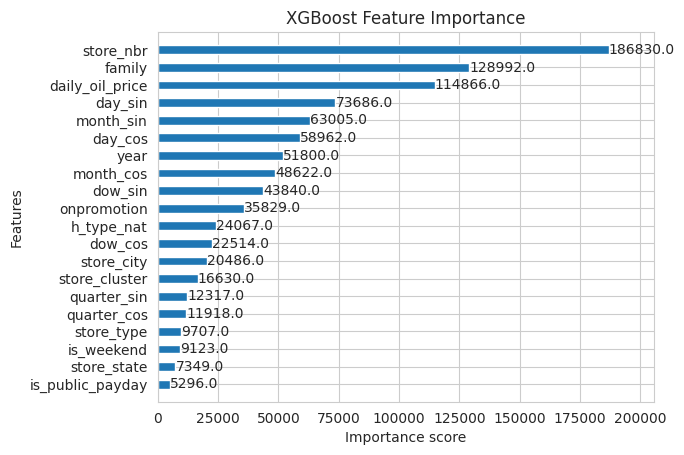

In [21]:
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_model, max_num_features=20, height=0.5, title="XGBoost Feature Importance")
plt.show()

## 2.3. LightGBM

In [23]:
import optuna
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from sklearn.metrics import mean_squared_error

def objective_lgb(trial):
    params = {
        'objective': 'rmse',
        'n_estimators': 3000,
        'random_state': 42,
        'n_jobs': -1,
        'device': 'gpu',
        'verbosity': -1,
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 6, 15),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
    }
    
    model = LGBMRegressor(**params)
    
    model.fit(
        X_train[FEATURES], 
        y_train_log,
        eval_set=[(X_val[FEATURES], y_val_log)],
        eval_metric='rmse',
        categorical_feature=cat_features,
        callbacks=[
            early_stopping(stopping_rounds=50, verbose=False)
        ]
    )
    
    preds_log = model.predict(X_val[FEATURES])
    rmse = np.sqrt(mean_squared_error(y_val_log, preds_log))
    
    return rmse

# --- OPTIMIZATION  ---
print("Starting LightGBM Hyperparameter Tuning (5 Runs)...")
study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=20)

print("\n------------------------------------------------")
print(f"BEST LGB TRIAL RMSE: {study_lgb.best_value:.5f}")
print("BEST LGB PARAMS: ")
for key, value in study_lgb.best_params.items():
    print(f"    {key}: {value}")
print("------------------------------------------------")

[I 2026-01-18 09:05:17,581] A new study created in memory with name: no-name-7fd1d825-e0f2-4457-ad51-1253be34541f


Starting LightGBM Hyperparameter Tuning (5 Runs)...


[I 2026-01-18 09:07:20,353] Trial 0 finished with value: 0.6064058514383323 and parameters: {'learning_rate': 0.060929584311187224, 'num_leaves': 114, 'max_depth': 12, 'min_child_samples': 76, 'subsample': 0.8397970702832394, 'colsample_bytree': 0.9243461572747216, 'reg_alpha': 7.521672176318292, 'reg_lambda': 2.1451178643161875}. Best is trial 0 with value: 0.6064058514383323.
[I 2026-01-18 09:08:17,725] Trial 1 finished with value: 0.6086628431384467 and parameters: {'learning_rate': 0.054237596381969594, 'num_leaves': 108, 'max_depth': 10, 'min_child_samples': 91, 'subsample': 0.613958575735939, 'colsample_bytree': 0.7600004978554037, 'reg_alpha': 2.9714849146317213, 'reg_lambda': 8.225418172167931}. Best is trial 0 with value: 0.6064058514383323.
[I 2026-01-18 09:11:59,994] Trial 2 finished with value: 0.6158008071217216 and parameters: {'learning_rate': 0.027314767657753716, 'num_leaves': 135, 'max_depth': 6, 'min_child_samples': 76, 'subsample': 0.798085088475204, 'colsample_bytr


------------------------------------------------
BEST LGB TRIAL RMSE: 0.59904
BEST LGB PARAMS: 
    learning_rate: 0.06945467340616776
    num_leaves: 97
    max_depth: 12
    min_child_samples: 41
    subsample: 0.9855852566202734
    colsample_bytree: 0.8157024049936074
    reg_alpha: 4.958780402614102
    reg_lambda: 3.351423529621793
------------------------------------------------


In [24]:
warnings.filterwarnings('ignore')

lgb_model = LGBMRegressor(
    objective='rmse',
    n_estimators=3000,
    learning_rate=0.06945467340616776,
    num_leaves=97,
    random_state=42,
    n_jobs=-1,
    device='gpu',
    verbosity=-1,
    max_depths= 12,
    min_child_samples= 41,
    subsample= 0.9855852566202734,
    colsample_bytree= 0.8157024049936074,
    reg_alpha= 4.958780402614102,
    reg_lambda= 3.351423529621793
)

lgb_model.fit(
    X_train[FEATURES],
    y_train_log,
    eval_set=[(X_val[FEATURES], y_val_log)],
    eval_metric='rmse',
    categorical_feature=cat_features,
    callbacks=[
        log_evaluation(100),
        early_stopping(50, verbose=False)
    ]
)

[100]	valid_0's rmse: 0.639586
[200]	valid_0's rmse: 0.617719
[300]	valid_0's rmse: 0.612898
[400]	valid_0's rmse: 0.609897
[500]	valid_0's rmse: 0.608783
[600]	valid_0's rmse: 0.607874
[700]	valid_0's rmse: 0.607185
[800]	valid_0's rmse: 0.606697
[900]	valid_0's rmse: 0.60623
[1000]	valid_0's rmse: 0.605666
[1100]	valid_0's rmse: 0.605447
[1200]	valid_0's rmse: 0.605208
[1300]	valid_0's rmse: 0.604905
[1400]	valid_0's rmse: 0.60467
[1500]	valid_0's rmse: 0.604291


LGBMRegressor(colsample_bytree=0.8157024049936074, device='gpu',
              learning_rate=0.06945467340616776, max_depths=12,
              min_child_samples=41, n_estimators=3000, n_jobs=-1, num_leaves=97,
              objective='rmse', random_state=42, reg_alpha=4.958780402614102,
              reg_lambda=3.351423529621793, subsample=0.9855852566202734,
              verbosity=-1)

In [25]:
lgb_pred_log = lgb_model.predict(X_val[FEATURES])

lgb_pred_real = np.expm1(lgb_pred_log)
lgb_pred_real = np.maximum(lgb_pred_real, 0)

try:
    lgb_rmsle = np.sqrt(mean_squared_log_error(y_val, lgb_pred_real))
    print(f"LightGBM Validation RMSLE: {lgb_rmsle:.5f}")
except Exception as e:
    print(f"Error calculating RMSLE: {e}")

# Evaluation metrics
LightGBM_metrics = evaluate_forecast(y_val, lgb_pred_real, y_train=y_train, seasonality=7)
print_metrics("LightGBM validation metrics", LightGBM_metrics)

LightGBM Validation RMSLE: 0.60391

LightGBM validation metrics
  MAE    : 97.78223
  RMSLE  :  0.60391
  sMAPE  :    0.565
  Bias   : -65.40509
  MASE   :  1.04475


In [26]:
lgb_profile = profile_trained_model(
    "lightgbm",
    predict_fn=lambda: lgb_model.predict(X_val[FEATURES]),
    n_rows=X_val[FEATURES].shape[0],
    save_fn=lambda path: lgb_model.booster_.save_model(path),
    run_twice=True
)

lgb_pred_log = lgb_profile["preds"]
print({k:v for k,v in lgb_profile.items() if k!="preds"})


NameError: name 'profile_trained_model' is not defined

**Feature Importance for LightGBM**

<Figure size 1000x800 with 0 Axes>

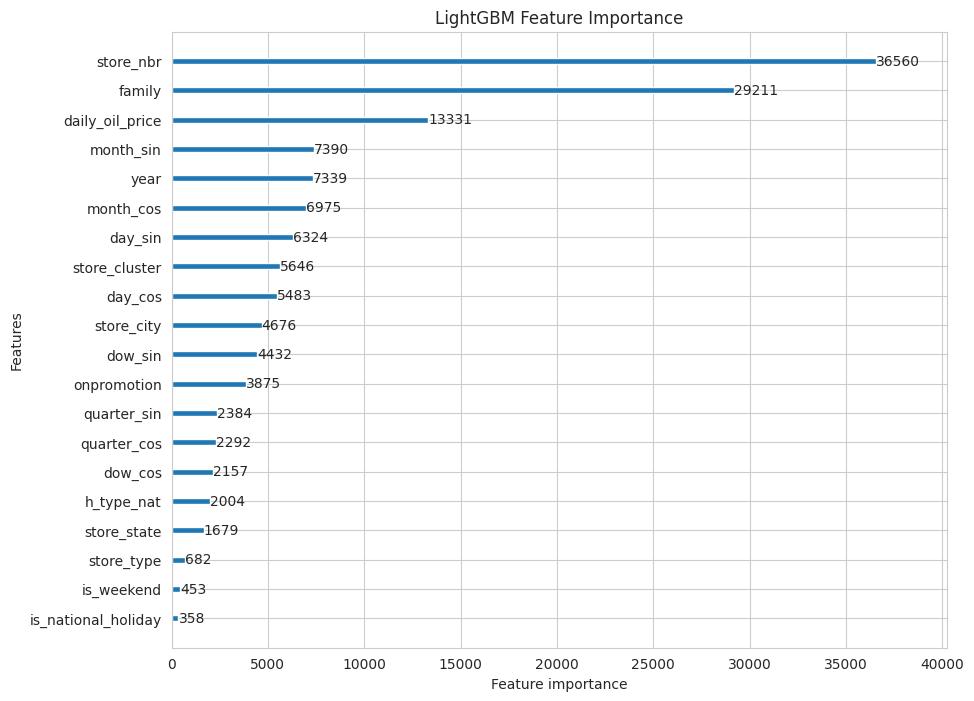

In [27]:
plt.figure(figsize=(10, 8))
lgb.plot_importance(lgb_model, max_num_features=20, figsize=(10, 8), title="LightGBM Feature Importance")
plt.show()

## 2.4. Ensemble

In [28]:
# Average of All three
final_predictions = (xgb_pred_real + cat_pred_real + lgb_pred_real) / 3

# Calculate the Ensemble Score
ensemble_rmsle = np.sqrt(mean_squared_log_error(y_val, final_predictions))

print(f"Ensemble Validation Score: {ensemble_rmsle:.5f}")

# Evaluation metrics
Ensemble_metrics = evaluate_forecast(y_val, final_predictions, y_train=y_train, seasonality=7)
print_metrics("Ensemble validation metrics", Ensemble_metrics)

Ensemble Validation Score: 0.58815

Ensemble validation metrics
  MAE    : 96.74705
  RMSLE  :  0.58815
  sMAPE  :    0.568
  Bias   : -68.59919
  MASE   :  1.03369


In [ ]:
profiles = [
    cat_profile,
    xgb_profile,
    lgb_profile,
]

summary = [
    {
        "model": p["model"],
        "predict_time_s": p["predict_time_s"],
        "rows_per_sec": p["rows_per_sec"],
        "ram_delta_mb": p["ram_delta_mb"],
        "model_size_mb": p["model_size_mb"],
        "stability_mean_abs_diff": p["stability_mean_abs_diff"],
    }
    for p in profiles
]

summary


# 3. Submission

In [29]:
# -----------------------------------------------------------------------------
# GENERATE TEST PREDICTIONS
# -----------------------------------------------------------------------------

print("Preparing Test Data...")

# 1. Prepare Test Feature Sets
# Standard for CatBoost/LGBM
X_test_cat = test[FEATURES].copy()

# Fixed strings for XGBoost (using the helper function defined earlier)
X_test_fixed = make_categories_strings(X_test_cat, CATEGORICAL)

print("Predicting with CatBoost...")
pred_log_cat = cat_model.predict(X_test_cat)

print("Predicting with XGBoost...")
pred_log_xgb = xgb_model.predict(X_test_fixed)

print("Predicting with LightGBM...")
pred_log_lgb = lgb_model.predict(X_test_cat)

# 2. Reverse Log Transformation & Clip Negatives
pred_real_cat = np.maximum(np.expm1(pred_log_cat), 0)
pred_real_xgb = np.maximum(np.expm1(pred_log_xgb), 0)
pred_real_lgb = np.maximum(np.expm1(pred_log_lgb), 0)

# 3. Ensemble Average
final_test_pred = (pred_real_cat + pred_real_xgb + pred_real_lgb) / 3

# 4. Create Submission File
submission = pd.DataFrame({
    'id': test['id'],
    'sales': final_test_pred
})

# Save
submission.to_csv('submission.csv', index=False)
print("Success! Submission saved to 'submission.csv'")

# Quick Sanity Check
print(submission.head())

Preparing Test Data...
Predicting with CatBoost...
Predicting with XGBoost...
Predicting with LightGBM...
Success! Submission saved to 'submission.csv'
        id     sales
0  3000888  3.711389
1  3002670  3.231022
2  3004452  3.516539
3  3006234  3.194391
4  3008016  1.330721


In [ ]:
print(pd.read_csv('submission.csv').head())